# 02 — W7-X ECRH Trace & Visualization

This notebook traces an ECRH beam through the Wendelstein 7-X (W7-X) stellarator equilibrium using the bundled equilibrium from `raytrax.examples.w7x`.

**You will learn how to:**
- Load the W7-X `MagneticConfiguration` from the built-in example
- Use the W7-X antenna geometry helper (`PortA`) to set a realistic beam position
- Convert physical aiming angles to a Cartesian beam direction
- Produce a polished R–Z beam-trace plot alongside the plasma profiles
- Read and interpret all fields of a `TraceResult`

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from raytrax import Beam, RadialProfiles, trace
from raytrax.examples.w7x import (
    PortA,
    get_w7x_magnetic_configuration,
    w7x_aiming_angles_to_direction,
)
from raytrax.plot.plot2d import (
    plot_beamtrace_rz,
    plot_effective_radius_rz,
    plot_electron_density_rz,
)

## 1 · Load the W7-X magnetic configuration

`get_w7x_magnetic_configuration()` runs VMEC++ on the bundled W7-X input file and caches the result as JSON so subsequent calls are instant.

In [2]:
mag_conf = get_w7x_magnetic_configuration()
print("Grid shape (R, φ, Z):", mag_conf.rphiz.shape[:3])

Grid shape (R, φ, Z): (45, 50, 55)


## 2 · Plasma profiles

Typical W7-X high-density scenario: $n_e \approx 1\times10^{20}$ m$^{-3}$, $T_e \approx 4$ keV on axis.

In [3]:
rho = jnp.linspace(0, 1, 200)
profiles = RadialProfiles(
    rho=rho,
    electron_density=1.0 * (1 - rho**2),  # 1e20 m⁻³ on axis
    electron_temperature=4.0 * (1 - rho**1.5),  # 4 keV on axis
)

## 3 · Beam from W7-X Port A

`PortA.D1` is the middle beam of the vertically stacked port-A launcher.
We use `w7x_aiming_angles_to_direction` to convert physical aiming angles (poloidal elevation, toroidal swing) to a Cartesian unit vector.

In [4]:
antenna = PortA.D1  # middle launcher of Port A

# Aiming: 5° poloidal elevation, 0° toroidal swing
direction = w7x_aiming_angles_to_direction(
    theta_pol_deg=5.0,
    theta_tor_deg=0.0,
    antenna_phi_deg=antenna.phi_deg,
)

beam = Beam(
    position=jnp.array(antenna.cartesian),
    direction=jnp.array(direction),
    frequency=140e9,  # Hz — 2nd-harmonic O-mode at ~2.52 T
    mode="O",
    power=1e6,
)
print(
    f"Antenna position : R={antenna.r:.3f} m, φ={antenna.phi_deg:.3f}°, Z={antenna.z:.3f} m"
)
print(f"Beam direction   : {np.round(direction, 4)}")

Antenna position : R=6.595 m, φ=0.094°, Z=0.000 m
Beam direction   : [-0.9962 -0.0016  0.0872]


## 4 · Trace

In [5]:
result = trace(mag_conf, profiles, beam)

print(f"Optical depth τ          = {result.optical_depth:.4f}")
print(f"Absorbed power fraction  = {result.absorbed_power_fraction:.1%}")
print(f"Absorbed power           = {result.absorbed_power / 1e3:.1f} kW")
print(
    f"Deposition ρ             = {result.deposition_rho_mean:.3f} ± {result.deposition_rho_std:.3f}"
)

Optical depth τ          = 0.7075
Absorbed power fraction  = 50.7%
Absorbed power           = 507.1 kW
Deposition ρ             = 0.133 ± 0.058


## 5 · R–Z cross-section plot

The left panel shows the electron density background; the right shows the beam power density overlaid on flux-surface contours.

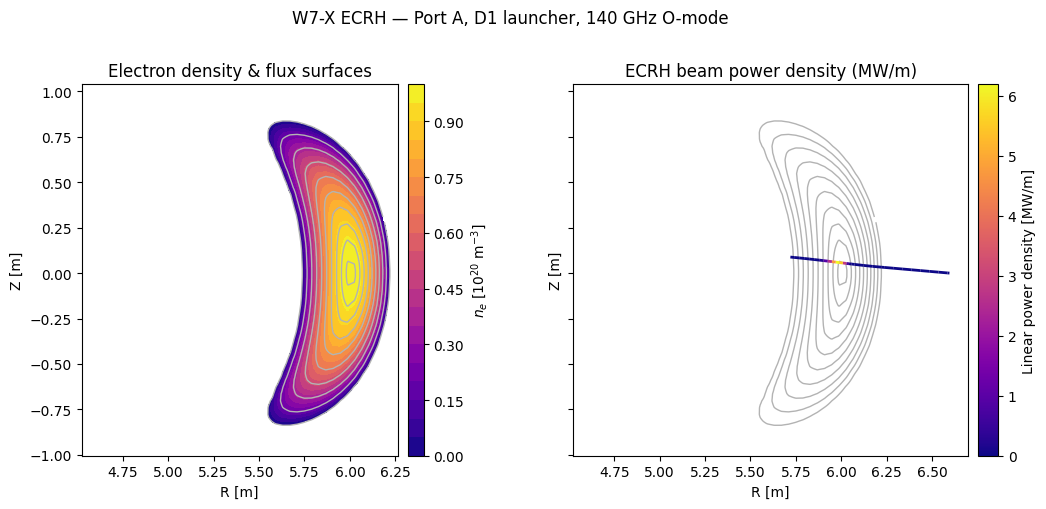

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# Left: electron density background + flux surfaces
plot_electron_density_rz(mag_conf, profiles, phi=0.0, ax=ax1)
plot_effective_radius_rz(mag_conf, phi=0.0, ax=ax1)
ax1.set_title("Electron density & flux surfaces")

# Right: beam trace on flux surfaces
plot_effective_radius_rz(mag_conf, phi=0.0, ax=ax2)
plot_beamtrace_rz(result.beam_profile, phi=0.0, ax=ax2, lw=2)
ax2.set_title("ECRH beam power density (MW/m)")

plt.suptitle("W7-X ECRH — Port A, D1 launcher, 140 GHz O-mode", y=1.01)
plt.tight_layout()
plt.show()

## 6 · 1D profiles along the ray

Inspect optical depth $\tau(s)$, linear power density $dP/ds(s)$, and volumetric deposition $dP/d\rho$ on the same figure.

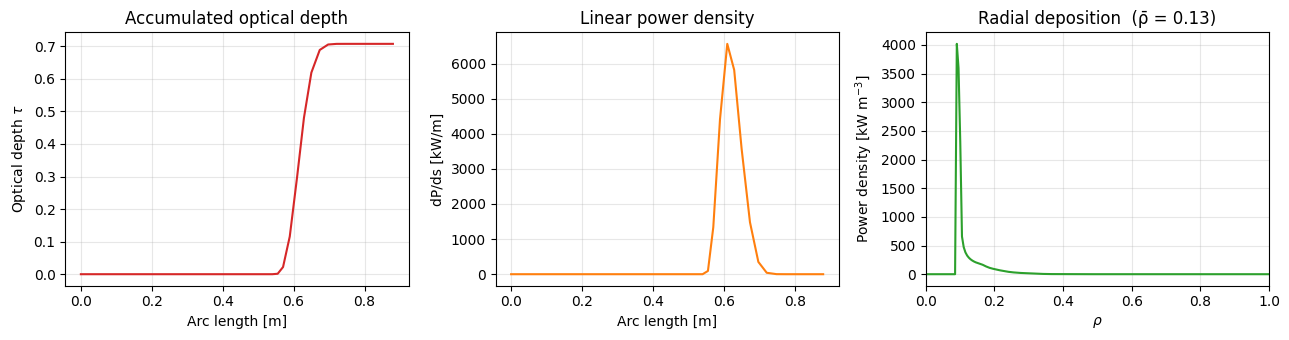

In [7]:
bp = result.beam_profile
s = np.array(bp.arc_length)
tau = np.array(bp.optical_depth)
lpd = np.array(bp.linear_power_density)

# Trim padding (diffrax fills unused slots with inf)
finite_mask = np.isfinite(s) & np.isfinite(tau)
s, tau, lpd = s[finite_mask], tau[finite_mask], lpd[finite_mask]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(s, tau, color="C3")
axes[0].set_xlabel("Arc length [m]")
axes[0].set_ylabel(r"Optical depth $\tau$")
axes[0].grid(alpha=0.3)
axes[0].set_title("Accumulated optical depth")

axes[1].plot(s, lpd / 1e3, color="C1")
axes[1].set_xlabel("Arc length [m]")
axes[1].set_ylabel("dP/ds [kW/m]")
axes[1].grid(alpha=0.3)
axes[1].set_title("Linear power density")

rho_r = np.array(result.radial_profile.rho)
pd_r = np.array(result.radial_profile.volumetric_power_density)
axes[2].plot(rho_r, pd_r / 1e3, color="C2")
axes[2].set_xlabel(r"$\rho$")
axes[2].set_ylabel(r"Power density [kW m$^{-3}$]")
axes[2].set_xlim(0, 1)
axes[2].grid(alpha=0.3)
axes[2].set_title(f"Radial deposition  (ρ̄ = {result.deposition_rho_mean:.2f})")

plt.tight_layout()
plt.show()